# 12 - Rail centrality and local socioeconomic profile

We want to combine the exact rail-network results with the CBS socioeconomic area assigned to each station. The main thing we are checking is whether the busiest, most central, or most damaging rail stations tend to sit in lower- or higher-cluster areas.

Our question is: **is a station's structural role in the rail graph related to the socioeconomic cluster around that station?**

We merge notebook 11's `rail_station_metrics.csv` and `single_station_damage.csv` with the stop-level socioeconomic match from notebook 09. We then compare the network measures with each other, create station archetypes, summarize socioeconomic bands and regions, and calculate rank correlations. The tables and four figures go under `outputs/nb/12_rail_socioeconomic/`.

This is only 67 stations, so there is no runtime problem. The difficult parts are interpretation: several centrality measures are near-duplicates, 23 stations use a nearest-polygon socioeconomic assignment, the district groups are small, and the continuous CBS index is unavailable in the current data.

## Set up the repository and output paths

We locate the project, switch into it, and create the shared notebook output folder. The package helper installs only what is missing and can clone the project in Colab. Every later path comes from `REPO`, `DATA`, and `OUT` defined here.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## Imports, thresholds, and metric families

We load the table, numerical, plotting, and statistical packages and create this notebook's stage folder.

`TOP_QUINTILE = 0.80` defines a high value for the archetype rules, and `PROFILE_TOP_N = 16` controls how many stations appear in the heatmap. We also group the measures into service volume, brokerage, and reach. That grouping matters when we build a composite score: averaging within families first prevents several strongly related service-volume measures from getting multiple votes just because they have different names.

In [2]:
_ensure("pandas", "numpy", "matplotlib", "seaborn", "scipy")

from itertools import cycle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid", font_scale=1.0)  # must run BEFORE the Hebrew font patch

STAGE = OUT / "12_rail_socioeconomic"
(STAGE / "tables").mkdir(parents=True, exist_ok=True)
(STAGE / "figures").mkdir(parents=True, exist_ok=True)

# ---- tunable constants -------------------------------------------------------
TOP_QUINTILE = 0.80      # "high" on a metric = top 20% of the 67 rail stations
PROFILE_TOP_N = 16       # rows in the multi-metric profile heatmap
FIG_DPI = 200

CENTRALITY_METRICS = [
    "degree",
    "weighted_degree",
    "pagerank",
    "betweenness",
    "harmonic",
]
DAMAGE_METRIC = "stations_outside_largest_component"
PROFILE_METRICS = CENTRALITY_METRICS + [DAMAGE_METRIC]
PROFILE_LABELS = {
    "degree": "Degree",
    "weighted_degree": "Service volume",
    "pagerank": "PageRank",
    "betweenness": "Betweenness",
    "harmonic": "Harmonic",
    DAMAGE_METRIC: "Single-outage damage",
}

# Grouping used by the family-balanced composite score.
CENTRALITY_FAMILIES = {
    "Service volume": ["degree", "weighted_degree", "pagerank"],
    "Brokerage": ["betweenness"],
    "Global accessibility": ["harmonic"],
}

print("Stage folder:", STAGE)

Stage folder: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/12_rail_socioeconomic


## Prepare Hebrew labels

This matplotlib build already displays Hebrew in the correct direction, so we keep station and region names in logical order and use a no-op `fix_he`. We select a font with Hebrew glyphs, turn off scientific offsets, and remove any leftover text patch that could reverse strings twice.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## Locate and load the three input tables

We search notebook 11's table folder for the rail metrics and single-station damage results, with a read-only fallback rail table location if that stage is not present. We separately locate `stops_with_socioeconomic.csv` under the notebook outputs.

All three joins use string `stop_id`. We print the chosen paths, table sizes, and a few rail rows so we can see that the graph run and socioeconomic match line up before deriving any scores.

In [4]:
RAIL_TABLE_NAMES = ["rail_station_metrics.csv", "single_station_damage.csv"]


def _find_stage_dir(prefix):
    """Return the first outputs/nb folder whose name starts with `prefix`."""
    matches = sorted(p for p in OUT.glob(prefix + "*") if p.is_dir())
    return matches[0] if matches else None


def resolve_rail_tables():
    stage_11 = _find_stage_dir("11_")
    if stage_11 is not None:
        tables = stage_11 / "tables"
        if all((tables / name).exists() for name in RAIL_TABLE_NAMES):
            print("Rail metrics source: notebook 11 stage outputs ->", tables)
            return tables
    fallback = REPO / "outputs" / "rail" / "tables"
    if all((fallback / name).exists() for name in RAIL_TABLE_NAMES):
        print("Rail metrics source: project-level fallback tables ->", fallback)
        print("  (notebook 11 stage output not found; the fallback is read-only)")
        return fallback
    raise FileNotFoundError(
        f"Missing {RAIL_TABLE_NAMES} in {OUT}/11_*/tables and in {fallback} - "
        "run notebook 11 (rail network analysis) first."
    )


def resolve_socioeconomic_csv():
    """Locate the CBS stop-to-statistical-area join produced by notebook 09."""
    for candidate in sorted(OUT.glob("*/tables/stops_with_socioeconomic.csv")):
        print("Socioeconomic source: notebook stage output ->", candidate)
        return candidate
    raise FileNotFoundError(
        f"stops_with_socioeconomic.csv not found under {OUT}/*/tables/. "
        "It is produced by notebook 09 (socioeconomic equity), which downloads the "
        "CBS 2021 statistical-area layer and joins every GTFS stop to it. "
        "Run 09_socioeconomic_equity.ipynb first."
    )


RAIL_TABLES = resolve_rail_tables()
SOCIO_CSV = resolve_socioeconomic_csv()

metrics = pd.read_csv(
    RAIL_TABLES / "rail_station_metrics.csv", dtype={"stop_id": str}, encoding="utf-8-sig"
)
damage = pd.read_csv(
    RAIL_TABLES / "single_station_damage.csv", dtype={"stop_id": str}, encoding="utf-8-sig"
)[["stop_id", DAMAGE_METRIC, "components"]]
socioeconomic = pd.read_csv(
    SOCIO_CSV, dtype={"stop_id": str}, encoding="utf-8-sig", low_memory=False
)

print(f"\nrail stations: {len(metrics)} | damage rows: {len(damage)} | "
      f"stops in socioeconomic join: {len(socioeconomic):,}")
metrics.head(3)

Rail metrics source: notebook 11 stage outputs -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/11_rail_network_analysis/tables
Socioeconomic source: notebook stage output -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/09_socioeconomic_equity/tables/stops_with_socioeconomic.csv

rail stations: 67 | damage rows: 67 | stops in socioeconomic join: 30,463


,stop_id,stop_code,stop_name,stop_lat,stop_lon,scheduled_stop_calls,degree,weighted_degree,in_degree,out_degree,pagerank,betweenness,harmonic,is_articulation_point,community_id
0,37292,17104,תל אביב ההגנה,32.053978,34.784839,752,8,1493,8,8,0.039443,0.537840,0.363366,True,5
1,37362,17034,הרצליה,32.163558,34.817406,599,8,846,8,8,0.022429,0.514608,0.363961,False,7
2,37358,17038,תל אביב מרכז,32.083715,34.798247,815,4,1543,4,4,0.031372,0.508625,0.330339,True,5


## Build one complete station analysis table

We merge rail metrics, closure damage, and selected socioeconomic fields on `stop_id` and require every rail station to receive an assignment. We split the observed CBS clusters into lower (2-4), middle (5-7), and higher (8-9) groups.

For degree, weighted degree, PageRank, betweenness, and harmonic centrality, we calculate percentile ranks across all 67 stations. We keep two damage ranks because they answer different questions:

- `damage_percentile_among_67` ranks the raw damage count across every station, including tied zeros;
- `damage_percentile_among_damaging` ranks only the 14 stations that actually strand another station and forces all other stations to zero.

The first is comparable with the centrality percentiles. The second is useful only for ordering the damaging subset. We also print exact-versus-nearest join counts, cluster range, fragmentation count, and group sizes.

In [5]:
SOCIO_COLUMNS = [
    "stop_id",
    "socio_locality",
    "socio_cluster",
    "socio_index_value",
    "socio_population",
    "socio_join_method",
    "socio_join_distance_m",
    "region",
    "metro",
]


def build_analysis_frame(metrics, damage, socioeconomic):
    frame = metrics.merge(damage, on="stop_id", how="left").merge(
        socioeconomic[SOCIO_COLUMNS], on="stop_id", how="left"
    )
    if frame["socio_cluster"].isna().any():
        missing = frame.loc[frame["socio_cluster"].isna(), "stop_name"].tolist()
        raise ValueError(f"Rail stations missing socioeconomic assignments: {missing}")

    # Booleans can survive a CSV round-trip as strings; normalise defensively.
    frame["is_articulation_point"] = (
        frame["is_articulation_point"].astype(str).str.strip().str.lower().isin(["true", "1"])
    )
    frame[DAMAGE_METRIC] = frame[DAMAGE_METRIC].fillna(0).astype(int)
    frame["components"] = frame["components"].fillna(1).astype(int)

    frame["socio_group"] = pd.cut(
        frame["socio_cluster"],
        bins=[0, 4, 7, 10],
        labels=["Lower (clusters 2-4)", "Middle (clusters 5-7)", "Higher (clusters 8-9)"],
    )

    for metric in CENTRALITY_METRICS:
        frame[f"{metric}_percentile"] = frame[metric].rank(method="average", pct=True)

    # Keep the two damage scales explicitly named so we do not mix their denominators.
    frame["damage_percentile_among_67"] = frame[DAMAGE_METRIC].rank(
        method="average", pct=True
    )
    frame["damage_percentile_among_damaging"] = 0.0
    damaging = frame[DAMAGE_METRIC] > 0
    frame.loc[damaging, "damage_percentile_among_damaging"] = frame.loc[
        damaging, DAMAGE_METRIC
    ].rank(method="average", pct=True)

    frame["top_quintile_centrality_count"] = sum(
        frame[f"{metric}_percentile"].ge(TOP_QUINTILE).astype(int)
        for metric in CENTRALITY_METRICS
    )
    return frame


frame = build_analysis_frame(metrics, damage, socioeconomic)

n_damaging = int((frame[DAMAGE_METRIC] > 0).sum())
print(f"stations: {len(frame)}")
print(f"socioeconomic join: {(frame.socio_join_method == 'within').sum()} within-polygon, "
      f"{(frame.socio_join_method == 'nearest').sum()} nearest-polygon")
print(f"CBS cluster range: {frame.socio_cluster.min():.0f}-{frame.socio_cluster.max():.0f}")
print(f"stations whose single removal separates others: {n_damaging} of {len(frame)}")
print("\nWhy the two damage scales differ (a non-fragmenting station):")
cols = ["stop_name", DAMAGE_METRIC, "damage_percentile_among_67", "damage_percentile_among_damaging"]
print(frame.sort_values(DAMAGE_METRIC, ascending=False)[cols].head(3).to_string(index=False))
print(frame.loc[frame[DAMAGE_METRIC] == 0, cols].head(2).to_string(index=False))
frame["socio_group"].value_counts().sort_index()

stations: 67
socioeconomic join: 44 within-polygon, 23 nearest-polygon
CBS cluster range: 2-9
stations whose single removal separates others: 14 of 67

Why the two damage scales differ (a non-fragmenting station):
    stop_name  stations_outside_largest_component  damage_percentile_among_67  damage_percentile_among_damaging
 תל אביב מרכז                                  33                    1.000000                          1.000000
תל אביב ההגנה                                  27                    0.985075                          0.928571
    חוף הכרמל                                  15                    0.970149                          0.857143
stop_name  stations_outside_largest_component  damage_percentile_among_67  damage_percentile_among_damaging
   הרצליה                                   0                    0.402985                               0.0
    השלום                                   0                    0.402985                               0.0


socio_group
Lower (clusters 2-4)     18
Middle (clusters 5-7)    28
Higher (clusters 8-9)    21
Name: count, dtype: int64

## Check metric redundancy before combining scores

We calculate a Spearman matrix for the five centrality measures, single-station damage, and scheduled stop calls. This tells us which columns contain distinct information.

We keep two composite scores:

- `composite_centrality_score_plain`, the plain mean of the five centrality percentiles;
- `composite_centrality_score_balanced`, the mean after first averaging within service volume, brokerage, and reach.

The second is our main ranking because weighted degree, PageRank, and scheduled calls are strongly related. We print the rank correlation between the two composites and the largest station-level rank shifts so the consequence of that weighting choice stays visible.

In [6]:
redundancy = frame[PROFILE_METRICS + ["scheduled_stop_calls"]].corr(method="spearman")
print("Spearman redundancy matrix (rail metrics):")
print(redundancy.round(3).to_string())
print(
    "\nweighted_degree vs scheduled_stop_calls: rho = "
    f"{redundancy.loc['weighted_degree', 'scheduled_stop_calls']:.3f}"
)

percentile_columns = [f"{m}_percentile" for m in CENTRALITY_METRICS]
frame["composite_centrality_score_plain"] = 100 * frame[percentile_columns].mean(axis=1)

family_scores = pd.DataFrame(
    {
        family: frame[[f"{m}_percentile" for m in members]].mean(axis=1)
        for family, members in CENTRALITY_FAMILIES.items()
    },
    index=frame.index,
)
frame["composite_centrality_score_balanced"] = 100 * family_scores.mean(axis=1)
# Canonical alias used by the ranking below.
frame["composite_centrality_score"] = frame["composite_centrality_score_balanced"]

composite_comparison = frame[["stop_id", "stop_name"]].copy()
composite_comparison["score_plain"] = frame["composite_centrality_score_plain"]
composite_comparison["score_balanced"] = frame["composite_centrality_score_balanced"]
composite_comparison["rank_plain"] = (
    frame["composite_centrality_score_plain"].rank(ascending=False, method="min").astype(int)
)
composite_comparison["rank_balanced"] = (
    frame["composite_centrality_score_balanced"].rank(ascending=False, method="min").astype(int)
)
composite_comparison["rank_shift"] = (
    composite_comparison["rank_plain"] - composite_comparison["rank_balanced"]
)

rho_scores = spearmanr(
    composite_comparison["score_plain"], composite_comparison["score_balanced"]
).statistic
print(f"\nPlain vs family-balanced composite: Spearman rho = {rho_scores:.3f}")
print("Largest ranking movers (positive shift = the balanced score ranks the station higher):")
movers = composite_comparison.reindex(
    composite_comparison["rank_shift"].abs().sort_values(ascending=False).index
).head(8)
print(movers[["stop_name", "rank_plain", "rank_balanced", "rank_shift"]].to_string(index=False))

Spearman redundancy matrix (rail metrics):
                                    degree  weighted_degree  pagerank  betweenness  harmonic  stations_outside_largest_component  scheduled_stop_calls
degree                               1.000            0.551     0.587        0.712     0.823                               0.465                 0.458
weighted_degree                      0.551            1.000     0.859        0.665     0.454                               0.380                 0.943
pagerank                             0.587            0.859     1.000        0.752     0.410                               0.517                 0.800
betweenness                          0.712            0.665     0.752        1.000     0.574                               0.568                 0.603
harmonic                             0.823            0.454     0.410        0.574     1.000                               0.366                 0.388
stations_outside_largest_component   0.465         

## Assign station archetypes

We classify each station using three signals: top-quintile service, top-quintile betweenness, and whether it is an articulation point whose removal actually strands other stations.

This separates several useful roles: a critical high-service hub is busy and damaging; a redundant high-service hub is busy but has alternatives; a branch gateway is not a high-service hub but still guards a branch; and a structural broker with alternatives has high betweenness without observed fragmentation. We print the total count and the socioeconomic-group breakdown for each category.

In [7]:
def classify_station(row):
    high_service = (
        row["weighted_degree_percentile"] >= TOP_QUINTILE
        and row["pagerank_percentile"] >= TOP_QUINTILE
    )
    high_brokerage = row["betweenness_percentile"] >= TOP_QUINTILE
    damaging_cut = bool(row["is_articulation_point"]) and row[DAMAGE_METRIC] > 0
    if high_service and damaging_cut:
        return "critical high-service hub"
    if high_service and not damaging_cut:
        return "redundant high-service hub"
    if high_brokerage and damaging_cut:
        return "structural bottleneck"
    if high_brokerage:
        return "structural broker with alternatives"
    if damaging_cut:
        return "branch gateway"
    if row["harmonic_percentile"] >= TOP_QUINTILE:
        return "globally accessible connector"
    return "ordinary or peripheral station"


frame["station_archetype"] = frame.apply(classify_station, axis=1)
print(frame["station_archetype"].value_counts().to_string())
print()
print("Archetype by socioeconomic group (station counts):")
print(
    pd.crosstab(frame["station_archetype"], frame["socio_group"]).to_string()
)

station_archetype
ordinary or peripheral station         41
critical high-service hub               7
branch gateway                          6
redundant high-service hub              5
globally accessible connector           4
structural broker with alternatives     3
structural bottleneck                   1

Archetype by socioeconomic group (station counts):
socio_group                          Lower (clusters 2-4)  Middle (clusters 5-7)  Higher (clusters 8-9)
station_archetype                                                                                      
branch gateway                                          1                      4                      1
critical high-service hub                               3                      3                      1
globally accessible connector                           1                      2                      1
ordinary or peripheral station                         10                     17                     14
redundant hi

## Figure 1 - compare centrality profiles and raw damage

We select the stations with the most top-quintile centrality appearances, breaking ties with the balanced composite. The left heatmap shows five percentiles, all ranked across the same 67 stations.

We place closure damage on a separate narrow panel in raw units: number of stations left outside the largest component. This avoids mixing a percentile across all stations with a percentile calculated only among damaging stations. Reading across one row now gives comparable ranks on the left and an absolute closure consequence on the right.

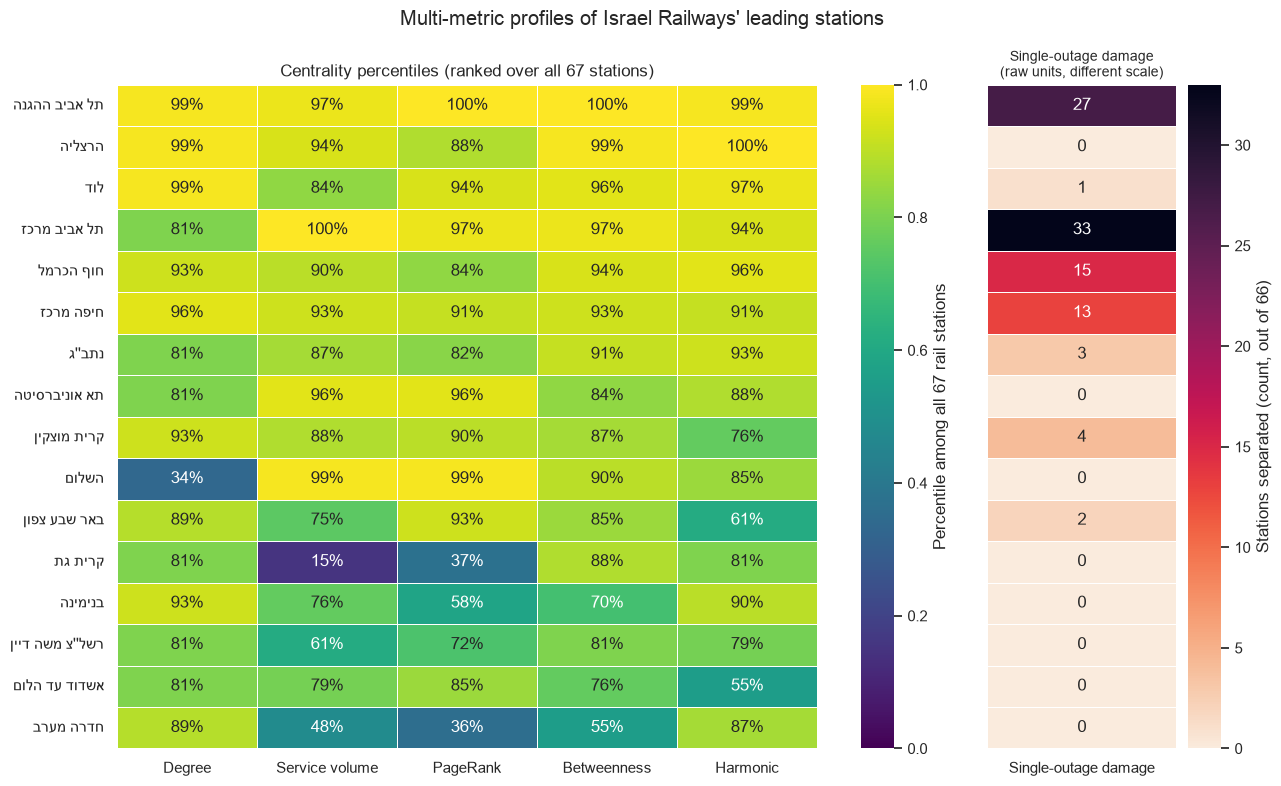

In [8]:
def plot_centrality_profiles(frame, path):
    ranking = frame.sort_values(
        ["top_quintile_centrality_count", "composite_centrality_score_balanced"],
        ascending=False,
    ).head(PROFILE_TOP_N)

    percentiles = ranking[[f"{m}_percentile" for m in CENTRALITY_METRICS]].copy()
    percentiles.columns = [PROFILE_LABELS[m] for m in CENTRALITY_METRICS]
    percentiles.index = list(ranking["stop_name"])

    damage_panel = ranking[[DAMAGE_METRIC]].copy()
    damage_panel.columns = [PROFILE_LABELS[DAMAGE_METRIC]]
    damage_panel.index = list(ranking["stop_name"])

    fig, axes = plt.subplots(
        1, 2, figsize=(13, 8), gridspec_kw={"width_ratios": [5, 1.35]}
    )
    sns.heatmap(
        percentiles,
        annot=True,
        fmt=".0%",
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0.4,
        cbar_kws={"label": "Percentile among all 67 rail stations"},
        ax=axes[0],
    )
    axes[0].set_title("Centrality percentiles (ranked over all 67 stations)")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")

    sns.heatmap(
        damage_panel,
        annot=True,
        fmt=".0f",
        cmap="rocket_r",
        vmin=0,
        vmax=int(frame[DAMAGE_METRIC].max()),
        linewidths=0.4,
        yticklabels=False,
        cbar_kws={"label": "Stations separated (count, out of 66)"},
        ax=axes[1],
    )
    axes[1].set_title("Single-outage damage\n(raw units, different scale)", fontsize=10)
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")

    fig.suptitle("Multi-metric profiles of Israel Railways' leading stations")
    fig.tight_layout()
    fig.savefig(path, dpi=FIG_DPI)
    return fig


fig = plot_centrality_profiles(frame, STAGE / "figures" / "centrality_profile_heatmap.png")
plt.show()

## Figure 2 - service volume versus fragmentation damage

We plot scheduled stop calls on a log x-axis against the number of other stations stranded by a one-station closure. Bubble size shows betweenness, and color shows the local socioeconomic cluster.

The bottom-right area contains busy stations with structural alternatives; the upper-left can reveal quieter branch gateways. We label stations with damage of at least three or traffic in the top 8%, using rotating offsets so multiple labels are not placed directly on top of each other.

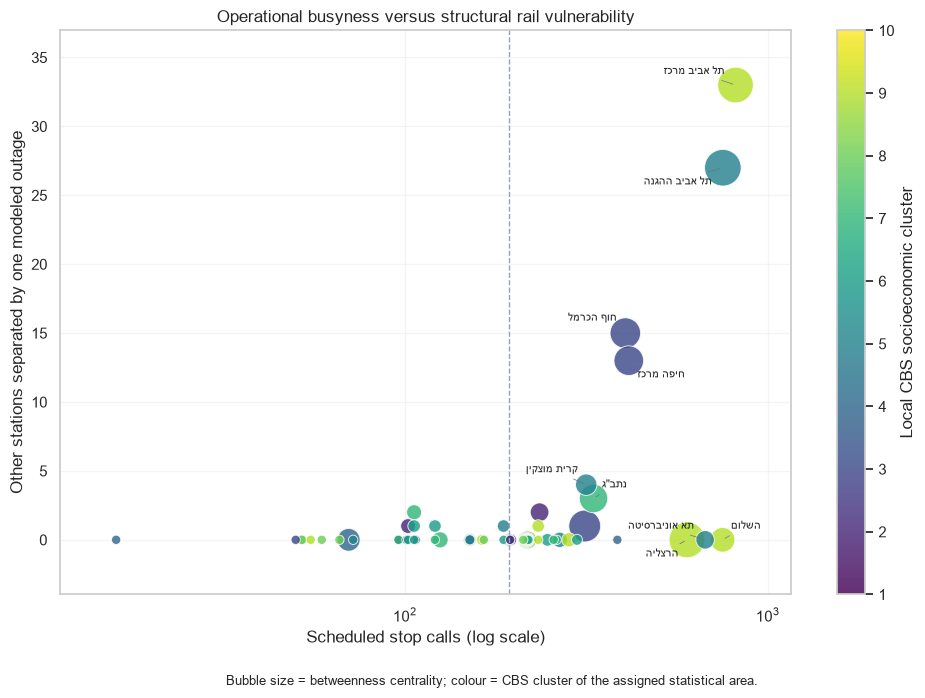

In [9]:
def plot_service_vs_damage(frame, path):
    fig, axis = plt.subplots(figsize=(10, 7))
    sizes = 45 + 650 * frame["betweenness"] / max(frame["betweenness"].max(), 1e-12)
    scatter = axis.scatter(
        frame["scheduled_stop_calls"],
        frame[DAMAGE_METRIC],
        c=frame["socio_cluster"],
        s=sizes,
        cmap="viridis",
        vmin=1,
        vmax=10,
        alpha=0.82,
        edgecolor="white",
        linewidth=0.7,
    )
    labels = frame[
        (frame[DAMAGE_METRIC] >= 3)
        | (frame["scheduled_stop_calls"] >= frame["scheduled_stop_calls"].quantile(0.92))
    ].sort_values(DAMAGE_METRIC, ascending=False)
    offsets = cycle(
        [(-8, 8), (-8, -12), (-6, 9), (6, -12), (-6, 9), (6, 8), (-6, -12), (6, 8)]
    )
    for (_, row), offset in zip(labels.iterrows(), offsets):
        axis.annotate(
            row["stop_name"],
            (row["scheduled_stop_calls"], row[DAMAGE_METRIC]),
            xytext=offset,
            textcoords="offset points",
            fontsize=8,
            ha="left" if offset[0] > 0 else "right",
            arrowprops={"arrowstyle": "-", "lw": 0.5, "color": "#64748b"},
        )
    axis.axvline(frame["scheduled_stop_calls"].median(), color="#94a3b8", ls="--", lw=1)
    axis.set_xscale("log")
    axis.set_xlabel("Scheduled stop calls (log scale)")
    axis.set_ylabel("Other stations separated by one modeled outage")
    axis.set_title("Operational busyness versus structural rail vulnerability")
    axis.margins(x=0.09, y=0.12)
    axis.grid(alpha=0.2)
    colorbar = fig.colorbar(scatter, ax=axis)
    colorbar.set_label("Local CBS socioeconomic cluster")
    fig.text(
        0.5,
        0.01,
        "Bubble size = betweenness centrality; colour = CBS cluster of the assigned statistical area.",
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    fig.savefig(path, dpi=FIG_DPI)
    return fig


fig = plot_service_vs_damage(frame, STAGE / "figures" / "service_vs_structural_damage.png")
plt.show()

## Summarize the three socioeconomic bands

We group the 67 stations into lower, middle, and higher CBS-cluster bands and calculate station count, exact-polygon share, mean degree, mean calls, mean betweenness, cut-vertex share, fragmentation count, and share of all calls.

The accompanying line chart compares mean percentile profiles across the three groups, with 0.5 as the network-wide midpoint. These are descriptive averages, not proof of a socioeconomic effect. The exact-match share is especially important because stations near the edge of a built-up area may inherit a nearest neighborhood that is not a good description of their users.

          socio_group  stations  within_polygon_share  mean_degree  mean_scheduled_stop_calls  mean_betweenness  articulation_point_share  stations_causing_fragmentation  scheduled_stop_call_share
 Lower (clusters 2-4)        18                 0.556        3.333                    188.778             0.088                     0.278                               5                      0.233
Middle (clusters 5-7)        28                 0.679        2.821                    216.643             0.055                     0.250                               7                      0.415
Higher (clusters 8-9)        21                 0.714        2.810                    244.619             0.079                     0.095                               2                      0.352


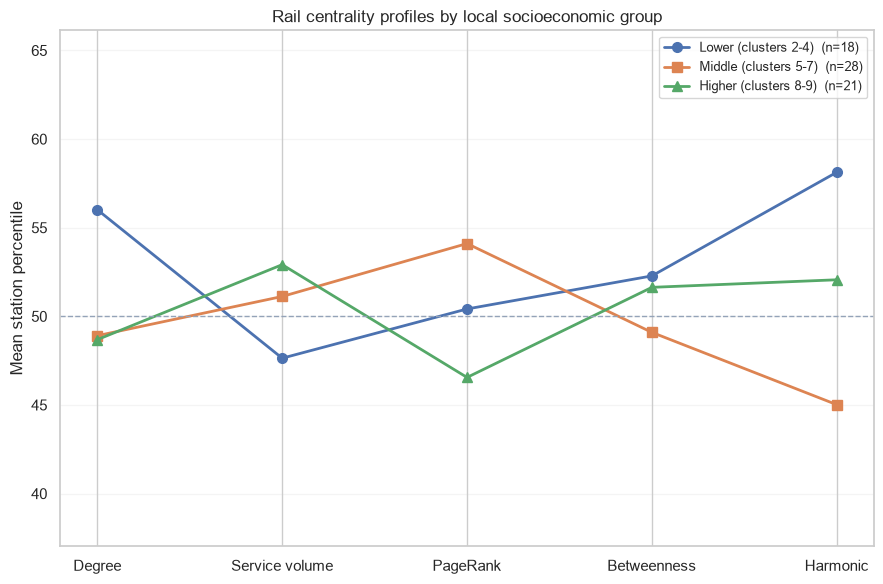

In [10]:
def group_summary(frame):
    summary = (
        frame.groupby("socio_group", observed=True)
        .agg(
            stations=("stop_id", "size"),
            within_polygon_share=("socio_join_method", lambda v: (v == "within").mean()),
            median_socio_cluster=("socio_cluster", "median"),
            mean_degree=("degree", "mean"),
            median_weighted_degree=("weighted_degree", "median"),
            mean_scheduled_stop_calls=("scheduled_stop_calls", "mean"),
            median_scheduled_stop_calls=("scheduled_stop_calls", "median"),
            total_scheduled_stop_calls=("scheduled_stop_calls", "sum"),
            mean_pagerank=("pagerank", "mean"),
            mean_betweenness=("betweenness", "mean"),
            median_betweenness=("betweenness", "median"),
            mean_harmonic=("harmonic", "mean"),
            articulation_point_share=("is_articulation_point", "mean"),
            stations_causing_fragmentation=(DAMAGE_METRIC, lambda v: (v > 0).sum()),
            mean_single_station_damage=(DAMAGE_METRIC, "mean"),
        )
        .reset_index()
    )
    summary["scheduled_stop_call_share"] = (
        summary["total_scheduled_stop_calls"] / summary["total_scheduled_stop_calls"].sum()
    )
    return summary


def plot_socioeconomic_profiles(frame, path):
    columns = [f"{m}_percentile" for m in CENTRALITY_METRICS]
    profile = frame.groupby("socio_group", observed=True)[columns].mean().T
    profile.index = [PROFILE_LABELS[m] for m in CENTRALITY_METRICS]
    counts = frame["socio_group"].value_counts()

    fig, axis = plt.subplots(figsize=(9, 6))
    for marker, group in zip(["o", "s", "^"], profile.columns):
        axis.plot(
            profile.index,
            100 * profile[group],
            marker=marker,
            linewidth=2,
            markersize=7,
            label=f"{group}  (n={int(counts[group])})",
        )
    axis.axhline(50, color="#94a3b8", ls="--", lw=1)
    axis.set_ylabel("Mean station percentile")
    axis.set_title("Rail centrality profiles by local socioeconomic group")
    low = float((100 * profile.values).min())
    high = float((100 * profile.values).max())
    axis.set_ylim(min(low, 50) - 8, max(high, 50) + 8)
    axis.grid(axis="y", alpha=0.2)
    axis.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(path, dpi=FIG_DPI)
    return fig


socioeconomic_groups = group_summary(frame)
display_cols = [
    "socio_group", "stations", "within_polygon_share", "mean_degree",
    "mean_scheduled_stop_calls", "mean_betweenness", "articulation_point_share",
    "stations_causing_fragmentation", "scheduled_stop_call_share",
]
print(socioeconomic_groups[display_cols].round(3).to_string(index=False))

fig = plot_socioeconomic_profiles(
    frame, STAGE / "figures" / "socioeconomic_centrality_profiles.png"
)
plt.show()

## Compare broad regions and show the sample sizes

We aggregate the same rail measures by Center, North, South, and Jerusalem and plot mean scheduled stop calls beside articulation-point share. Every bar includes `n`. The groups are very unequal—39, 18, 7, and 3 stations—so we use this as context rather than as a stable ranking, especially for Jerusalem and the South.

 region  stations  mean_socio_cluster  mean_scheduled_stop_calls  total_scheduled_stop_calls  mean_betweenness  mean_harmonic  articulation_point_share  mean_single_station_damage
   מרכז        39               6.410                    237.538                        9264             0.090          0.263                     0.128                       1.667
   צפון        18               5.833                    215.611                        3881             0.060          0.241                     0.389                       2.056
   דרום         7               4.571                    139.714                         978             0.023          0.209                     0.143                       0.286
ירושלים         3               4.667                    159.333                         478             0.010          0.238                     0.333                       0.333


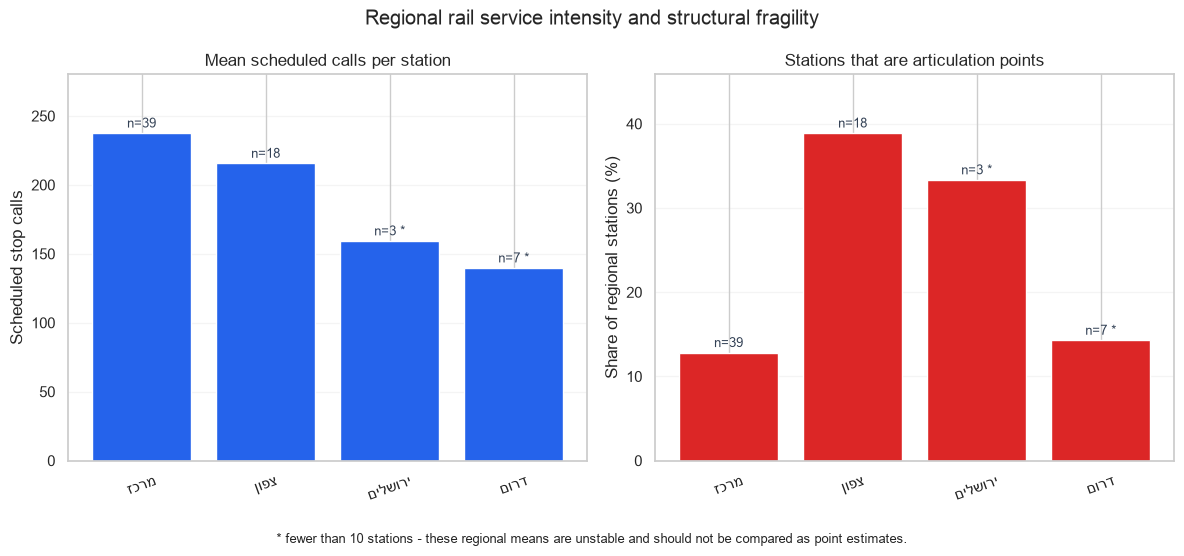

In [11]:
def regional_summary(frame):
    summary = (
        frame.groupby("region", dropna=False)
        .agg(
            stations=("stop_id", "size"),
            mean_socio_cluster=("socio_cluster", "mean"),
            mean_scheduled_stop_calls=("scheduled_stop_calls", "mean"),
            total_scheduled_stop_calls=("scheduled_stop_calls", "sum"),
            mean_betweenness=("betweenness", "mean"),
            mean_harmonic=("harmonic", "mean"),
            articulation_point_share=("is_articulation_point", "mean"),
            mean_single_station_damage=(DAMAGE_METRIC, "mean"),
        )
        .reset_index()
    )
    return summary.sort_values("mean_betweenness", ascending=False)


def plot_regional_profile(summary, path, small_group_threshold=10):
    ordered = summary.sort_values("mean_scheduled_stop_calls", ascending=False)
    labels = list(ordered["region"])
    counts = list(ordered["stations"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    panels = [
        (ordered["mean_scheduled_stop_calls"], "#2563eb",
         "Mean scheduled calls per station", "Scheduled stop calls"),
        (100 * ordered["articulation_point_share"], "#dc2626",
         "Stations that are articulation points", "Share of regional stations (%)"),
    ]
    for axis, (values, colour, title, ylabel) in zip(axes, panels):
        bars = axis.bar(labels, values, color=colour)
        axis.set_title(title)
        axis.set_ylabel(ylabel)
        axis.tick_params(axis="x", rotation=20)
        axis.grid(axis="y", alpha=0.2)
        axis.margins(y=0.18)
        # Show n on every bar and flag the small groups explicitly.
        for bar, n in zip(bars, counts):
            note = f"n={n}" + (" *" if n < small_group_threshold else "")
            axis.annotate(
                note,
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                fontsize=9,
                color="#334155",
            )
    fig.suptitle("Regional rail service intensity and structural fragility")
    fig.text(
        0.5,
        0.01,
        f"* fewer than {small_group_threshold} stations - these regional means are unstable "
        "and should not be compared as point estimates.",
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    fig.savefig(path, dpi=FIG_DPI)
    return fig


regions = regional_summary(frame)
print(regions.round(3).to_string(index=False))

fig = plot_regional_profile(regions, STAGE / "figures" / "regional_rail_profile.png")
plt.show()

## Test socioeconomic cluster against the rail measures

We lay out Spearman rows for two socioeconomic variables, six network measures, and two samples: all assignments and exact point-in-polygon assignments. The intended table therefore has 24 rows, but a row is only a real test when both variables contain data.

In the current input, `socio_index_value` is entirely missing. Its 12 rows have `n = 0`, rho and p-value `NaN`, and must not be counted as tests. That leaves 12 valid cluster-based correlations. The adjustment functions operate only on those 12 finite p-values and leave the unavailable rows as `NaN`. None of the valid raw, Benjamini-Hochberg, or Holm values is below 0.05.

For the usable rows we focus on rho, raw p-value, sample size, and whether the exact-match subset tells the same qualitative story.

In [12]:
def benjamini_hochberg(p_values):
    """BH false-discovery-rate adjusted p-values (q-values)."""
    p = np.asarray(p_values, dtype=float)
    out = np.full(p.shape, np.nan)
    valid = np.isfinite(p)
    finite_p = p[valid]
    n = finite_p.size
    if n == 0:
        return out
    order = np.argsort(finite_p)
    scaled = finite_p[order] * n / np.arange(1, n + 1)
    monotone = np.minimum.accumulate(scaled[::-1])[::-1]
    restored = np.empty(n)
    restored[order] = np.clip(monotone, 0, 1)
    out[valid] = restored
    return out


def holm_bonferroni(p_values):
    """Holm-Bonferroni family-wise-error adjusted p-values."""
    p = np.asarray(p_values, dtype=float)
    out = np.full(p.shape, np.nan)
    valid = np.isfinite(p)
    finite_p = p[valid]
    n = finite_p.size
    if n == 0:
        return out
    order = np.argsort(finite_p)
    scaled = finite_p[order] * (n - np.arange(n))
    monotone = np.maximum.accumulate(scaled)
    restored = np.empty(n)
    restored[order] = np.clip(monotone, 0, 1)
    out[valid] = restored
    return out


def correlation_table(frame):
    rows = []
    samples = {
        "all assignments": frame,
        "within-polygon only": frame[frame["socio_join_method"] == "within"],
    }
    for sample_name, sample in samples.items():
        for socio_variable in ["socio_cluster", "socio_index_value"]:
            for metric in PROFILE_METRICS:
                subset = sample[[socio_variable, metric]].dropna()
                rho, p_value = spearmanr(subset[socio_variable], subset[metric])
                rows.append(
                    {
                        "sample": sample_name,
                        "socioeconomic_variable": socio_variable,
                        "network_metric": metric,
                        "spearman_rho": float(rho),
                        "p_value_two_sided": float(p_value),
                        "n_stations": len(subset),
                    }
                )
    table = pd.DataFrame(rows)
    table["q_value_bh"] = benjamini_hochberg(table["p_value_two_sided"])
    table["p_value_holm"] = holm_bonferroni(table["p_value_two_sided"])
    table["significant_after_correction"] = table["q_value_bh"] < 0.05
    return table


correlations = correlation_table(frame)
print(
    correlations.round(4).to_string(index=False)
)

valid_tests = correlations.dropna(subset=["p_value_two_sided"])
strongest = valid_tests.loc[valid_tests["spearman_rho"].abs().idxmax()]
smallest_p = valid_tests.loc[valid_tests["p_value_two_sided"].idxmin()]
print(f"\n--- result summary for {len(correlations)} attempted rows "
      f"({len(valid_tests)} valid tests) ---")
print(f"attempted rows: {len(correlations)}")
print(f"valid tests: {len(valid_tests)}")
print(f"raw p < 0.05: {(correlations['p_value_two_sided'] < 0.05).sum()}")
print(f"BH q < 0.05: {(correlations['q_value_bh'] < 0.05).sum()}")
print(f"Holm p < 0.05: {(correlations['p_value_holm'] < 0.05).sum()}")
print(
    f"largest |rho|: {strongest.spearman_rho:+.3f} "
    f"({strongest.network_metric}, {strongest.socioeconomic_variable}, {strongest['sample']}, "
    f"raw p={strongest.p_value_two_sided:.3f})"
)
print(
    f"smallest raw p: {smallest_p.p_value_two_sided:.3f} "
    f"({smallest_p.network_metric}, {smallest_p['sample']}) -> "
    f"BH q={smallest_p.q_value_bh:.3f}"
)
print(
    "Interpretation: with n=67 (44 within-polygon) even a moderate true effect of |rho| ~ 0.24 "
    "would be needed for raw significance, so this is an underpowered null result, not evidence "
    "of exact equality."
)

             sample socioeconomic_variable                     network_metric  spearman_rho  p_value_two_sided  n_stations  q_value_bh  p_value_holm  significant_after_correction
    all assignments          socio_cluster                             degree       -0.1266             0.3075          67      0.8824        1.0000                         False
    all assignments          socio_cluster                    weighted_degree        0.0752             0.5453          67      0.8824        1.0000                         False
    all assignments          socio_cluster                           pagerank       -0.0544             0.6618          67      0.8824        1.0000                         False
    all assignments          socio_cluster                        betweenness       -0.0237             0.8488          67      0.9259        1.0000                         False
    all assignments          socio_cluster                           harmonic       -0.0892             0

## Save the station table and all summaries

We write the complete archetype table, centrality correlation matrix, plain-versus-balanced ranking comparison, socioeconomic and regional summaries, and correlation table as UTF-8 CSV files. The station table is sorted by the balanced composite but retains both composite definitions and both damage-rank definitions. We also list all table and figure sizes as a final completion check.

In [13]:
tables_dir = STAGE / "tables"

frame.sort_values("composite_centrality_score_balanced", ascending=False).to_csv(
    tables_dir / "rail_station_archetypes.csv", index=False, encoding="utf-8-sig"
)
correlations.to_csv(
    tables_dir / "rail_socioeconomic_correlations.csv", index=False, encoding="utf-8-sig"
)
redundancy.to_csv(tables_dir / "rail_centrality_spearman.csv", encoding="utf-8-sig")
composite_comparison.sort_values("rank_balanced").to_csv(
    tables_dir / "composite_score_comparison.csv", index=False, encoding="utf-8-sig"
)
socioeconomic_groups.to_csv(
    tables_dir / "rail_socioeconomic_group_summary.csv", index=False, encoding="utf-8-sig"
)
regions.to_csv(
    tables_dir / "rail_regional_summary.csv", index=False, encoding="utf-8-sig"
)

for path in sorted(STAGE.rglob("*")):
    if path.is_file():
        print(path.relative_to(OUT), f"({path.stat().st_size / 1024:.1f} KB)")

12_rail_socioeconomic/figures/centrality_profile_heatmap.png (338.9 KB)
12_rail_socioeconomic/figures/regional_rail_profile.png (91.2 KB)
12_rail_socioeconomic/figures/service_vs_structural_damage.png (152.6 KB)
12_rail_socioeconomic/figures/socioeconomic_centrality_profiles.png (127.9 KB)
12_rail_socioeconomic/tables/composite_score_comparison.csv (4.6 KB)
12_rail_socioeconomic/tables/rail_centrality_spearman.csv (1.0 KB)
12_rail_socioeconomic/tables/rail_regional_summary.csv (0.7 KB)
12_rail_socioeconomic/tables/rail_socioeconomic_correlations.csv (2.3 KB)
12_rail_socioeconomic/tables/rail_socioeconomic_group_summary.csv (1.0 KB)
12_rail_socioeconomic/tables/rail_station_archetypes.csv (28.1 KB)


## Conclusions

1. **We do not detect a socioeconomic relationship in this 67-station sample.** Among the 12 estimable tests using `socio_cluster`, none has raw `p < 0.05`. The largest absolute estimate is rho `-0.267` for single-station damage in the 44 exact-polygon stations (`p = 0.079`). This is an underpowered null result: it means we do not have evidence of a systematic relationship, not that centrality is exactly equal across socioeconomic areas.

2. **The continuous socioeconomic index cannot be analyzed here.** It contains no usable values, so the 12 table rows involving `socio_index_value` have `n = 0` and are missing results rather than negative tests. We should describe this run as 12 valid correlations, not 24 completed hypothesis tests.

3. **The descriptive group averages point in different directions.** Mean scheduled calls rise from 188.8 in the lower group to 216.6 in the middle and 244.6 in the higher group. At the same time, articulation-point share falls from 27.8% and 25.0% to 9.5%. Those differences are interesting context, but the station-level tests do not establish them as a general socioeconomic pattern.

4. **Service volume and structural fragility are not interchangeable.** The archetypes include seven critical high-service hubs and six branch gateways. The branch gateways are the clearest reason not to prioritize stations using traffic alone: they can have moderate service yet still be the only connection to part of the graph.

5. **The composite ranking is stable overall but not identical station by station.** Weighted degree and scheduled calls have rho `0.943`, so a plain average overweights the service-volume family. The plain and family-balanced rankings still correlate at `0.984`, but individual stations move as many as ten positions. We use the balanced score as a summary, not as a uniquely correct importance order.

6. **Spatial assignment and small groups limit the equity interpretation.** Only 44 stations fall inside their assigned CBS polygon; 23 use the nearest polygon. Region sizes range from 39 stations in the Center to only three in Jerusalem. The socioeconomic value describes the area around the station, not the riders using it, and the rail graph represents scheduled topology rather than passenger demand.